In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ajouter le dossier 'src' au chemin pour pouvoir importer les scripts
sys.path.append(os.path.abspath('../'))

from src.preprocessing import clean_sequence_file, save_processed_data
import pandas as pd

In [3]:
#Cellule 2 : Exécution du nettoyage 
# Chemins des fichiers
raw_data = "../data/raw/adn_data.txt" # Assure-toi que le nom correspond
processed_data = "../data/processed/cleaned_data.csv"

# Appel de la fonction de nettoyage
df_cleaned = clean_sequence_file(raw_data)

# Affichage des premières lignes pour vérification
print(f"Nombre total de séquences : {len(df_cleaned)}")
df_cleaned.head()

Nombre total de séquences : 87


,sequence,target
0,MPATSSIITIIAVAACLLLLVADAHAQQQCNWQYGLTTMDIRCSVR...,0
1,MRRKMKLFLFLLLVINICRSAAANGDECPKFCKCAPDPVQPTSKLL...,0
2,MAFIRQAPFLRCLPLVLLCILTPTLIQTIHQDAMLTSSMKCHYDAE...,0
3,EKTEYRSEVEEIQQEDFLPLQNTTISNLTLTANKIQILQPQSFLHL...,0
4,MSFKHPSSLFPSLVMAFLLPLTLQAFQGDSMEIVSSGLHTGSVRRG...,0


In [4]:
# Vérifier l'équilibre des classes
print("Répartition des classes :")
print(df_cleaned['target'].value_counts())

# Calculer la longueur des séquences (juste pour vérification)
df_cleaned['length'] = df_cleaned['sequence'].apply(len)
print("\nStatistiques sur la longueur des séquences :")
print(df_cleaned.groupby('target')['length'].describe())

Répartition des classes :
target
1    47
0    40
Name: count, dtype: int64

Statistiques sur la longueur des séquences :
        count        mean         std    min     25%    50%    75%     max
target                                                                    
0        40.0  884.550000  140.962434  639.0  791.25  838.5  943.5  1389.0
1        47.0  667.297872  209.272229  203.0  448.50  760.0  815.5   956.0


In [5]:
# Sauvegarder pour l'étape suivante (K-means)
save_processed_data(df_cleaned, processed_data)
print("Données sauvegardées dans data/processed/cleaned_data.csv")

Données sauvegardées dans data/processed/cleaned_data.csv


C:\Users\lenovo\AppData\Local\Temp\ipykernel_24804\2885406403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_cleaned, palette='viridis')


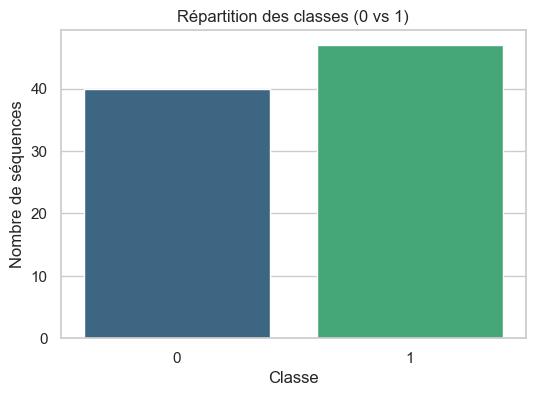

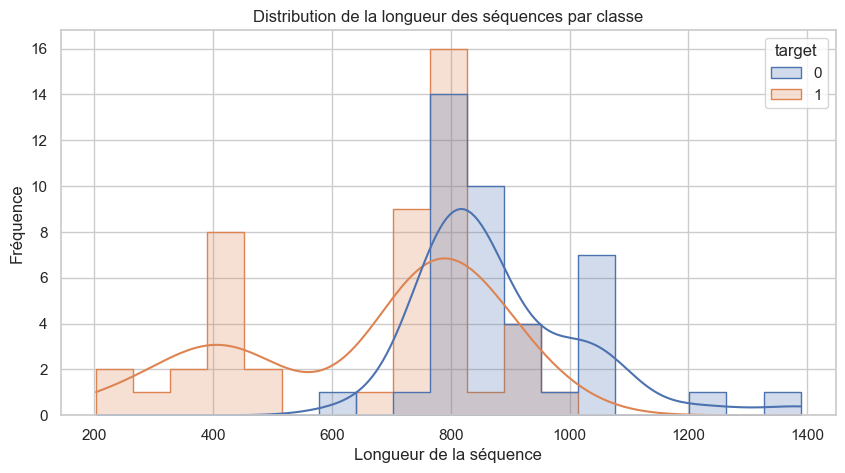

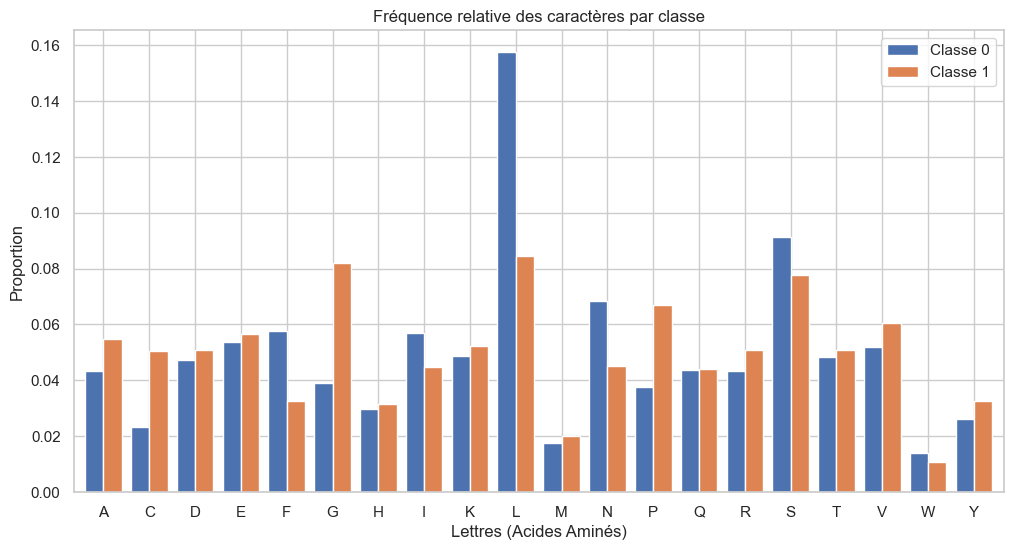

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- GRAPHIQUE 1 : Distribution des Classes ---
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_cleaned, palette='viridis')
plt.title("Répartition des classes (0 vs 1)")
plt.xlabel("Classe")
plt.ylabel("Nombre de séquences")
plt.savefig('../outputs/figures/class_distribution.png')
plt.show()

# --- GRAPHIQUE 2 : Distribution des Longueurs ---
# On calcule la longueur de chaque séquence
df_cleaned['length'] = df_cleaned['sequence'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_cleaned, x='length', hue='target', kde=True, element="step")
plt.title("Distribution de la longueur des séquences par classe")
plt.xlabel("Longueur de la séquence")
plt.ylabel("Fréquence")
plt.savefig('../outputs/figures/length_distribution.png')
plt.show()

# --- GRAPHIQUE 3 : Fréquence des Caractères (Analyse de composition) ---
def get_char_freq(sequences):
    all_text = "".join(sequences)
    counts = Counter(all_text)
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

freq_0 = get_char_freq(df_cleaned[df_cleaned['target'] == 0]['sequence'])
freq_1 = get_char_freq(df_cleaned[df_cleaned['target'] == 1]['sequence'])

# Transformation en DataFrame pour le graphique
df_freq = pd.DataFrame([freq_0, freq_1], index=['Classe 0', 'Classe 1']).T.fillna(0)
df_freq = df_freq.sort_index()

df_freq.plot(kind='bar', width=0.8)
plt.title("Fréquence relative des caractères par classe")
plt.xlabel("Lettres (Acides Aminés)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend()
plt.savefig('../outputs/figures/char_frequency.png')
plt.show()

Fichier sauvegardé dans : ../data/raw/adn_dataset.csv
